# Swarm Intelligence Workbook

In [1]:
import numpy as np

In [ ]:
N: int = 100 # Number of particles
D: int = 2 # Size of each particle
T: int = 60 # Number of iterations
from typing import Literal

type Swarm =\
        np.ndarray[tuple[Literal['N'],
                         Literal['D']],
                   np.dtype[np.int32]]

type Particle =\
        np.ndarray[tuple[Literal['D']],
                   np.dtype[np.int32]]

## Define the Swarm

Define variable $\mathrm{X}$ that represents the swarm. $\mathrm{X}$ is a $N\times D$ matrix, where $\mathrm{x}_{n,n\in [1,\dots, N]}$ is the $n^{\mathrm{th}}$ solution and $x_{n,d}, d\in [1,\dots, D]$ is the $d^{\mathrm{th}}$ item in that solution. $\mathrm{Y}$ stores personal bests such that $\mathrm{Y}_n$ is the personal best of $\mathrm{X}_n$.

Also, define variable $X_T$ that stores the history of $X$. Each $X_T[t]$ should be $X$ at time step $t$. Also define $Y_T$.

In [3]:
from typing import Callable, Any
import random

# The domain of Any, Any is hard-coded according
#   to D=2.
INITIALISER: Callable[[int, int], float] =\
    lambda _1, _2: np.random.uniform(low = -10, high= -8)

X: Swarm = np.fromfunction(np.vectorize(INITIALISER),
                           shape=(N, D),
                           dtype=float)
Y: Swarm = np.copy(X)

V: Swarm = np.zeros(shape=(N, D),
                    dtype=float)

X_T = []
Y_T = []

### Problem and Measure of Success

Define a problem represented by `OBJECTIVE`. Also define `is_better_than`, a way to compare two fitnesses.

In [4]:
import ograph.ofunc as ofunc

OBJECTIVE: Callable[[Particle],
                    float] =\
    lambda x: -ofunc.rosenbrock(*x)

is_better_than: Callable[[float, float],
                         bool] =\
    lambda x, y: x > y

In [5]:
# Initialising y_hat to X[0] is arbitrary.
# Would be more "correct" to use Optional.
y_hat: Particle = X[0]
fy_hat: float = OBJECTIVE(y_hat)
y_hat_T: list[Particle] = []
fy_hat_T: list[float] = []

assert X.shape == (N, D)
assert Y.shape == (N, D)
assert V.shape == (N, D)

C_1: float = 1
C_2: float = 1

for _ in range(T):
    # For each iteration:
    # For each particle in swarm:
    for i in range(N):
        fy_i = OBJECTIVE(Y[i])
        fx_i = OBJECTIVE(X[i])

        if is_better_than(fx_i,
                          fy_i):
            Y[i] = X[i]
            fy_i = fx_i

        if is_better_than(fy_i,
                          fy_hat):
            y_hat = Y[i]
            fy_hat = fy_i
    
    for i in range(N):
        for j in range(len(V[i])):
            r_1j: float = np.random.uniform(0, 1)
            r_2j: float = np.random.uniform(0, 1)
            V[i][j] = V[i][j] +\
                C_1 * r_1j * (Y[i][j]-X[i][j]) +\
                C_2 * r_2j * (y_hat[j]-X[i][j])
            
        X[i] = X[i] + V[i]


    X_T.append(X.copy())
    Y_T.append(Y.copy())
    y_hat_T.append(y_hat)
    fy_hat_T.append(fy_hat)

## Visualisation

Visualise the training process.

### Plot Past Solutions

Plot past values of $\mathrm{X}$. Recall that $\mathrm{X}_T[t]$ is $\mathrm{X}$ at time $t$.

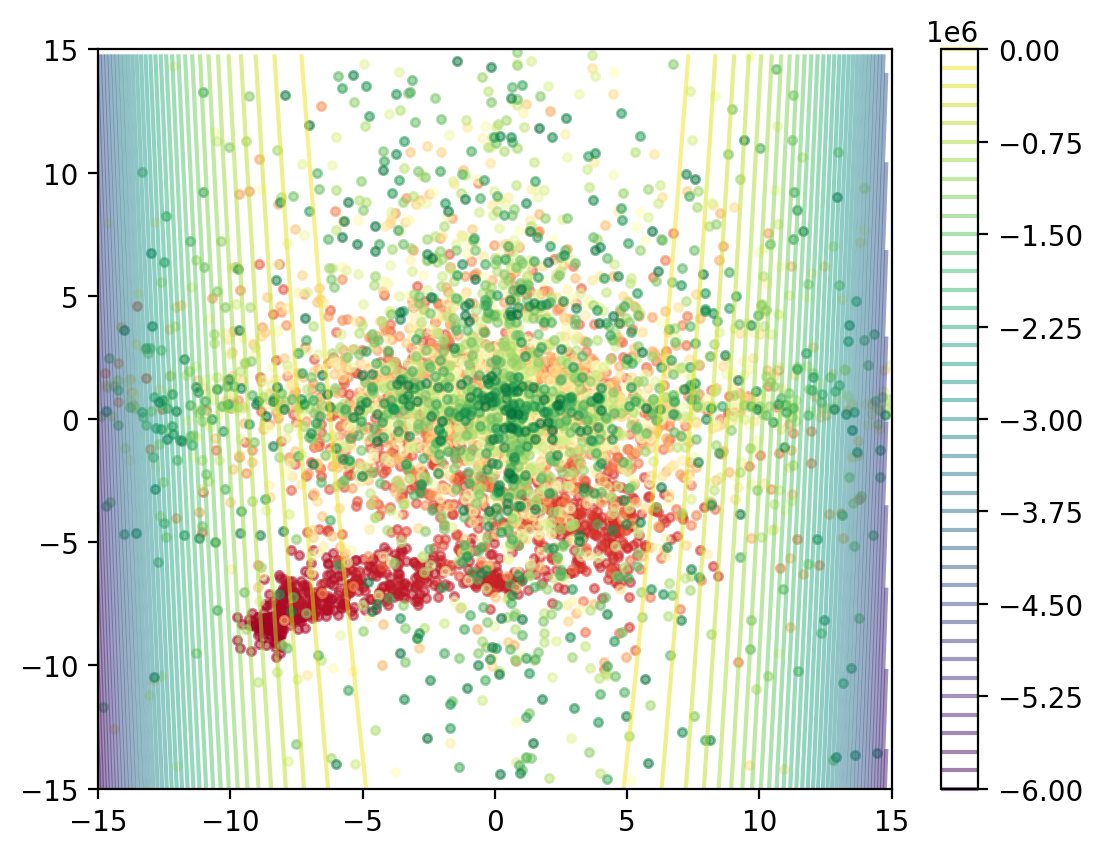

In [19]:
from ograph.applications.swarm import plot_positions, plot_bests
from ograph.oplot import high_res

high_res()
mort = np.array(X_T)
plot_positions(mort[:,:,:], lambda x, y: OBJECTIVE((x, y)), override_region=((-15, 15), (-15, 15)))

### Plot Past Fitnesses

Plot past values of $f(\hat{y})$.

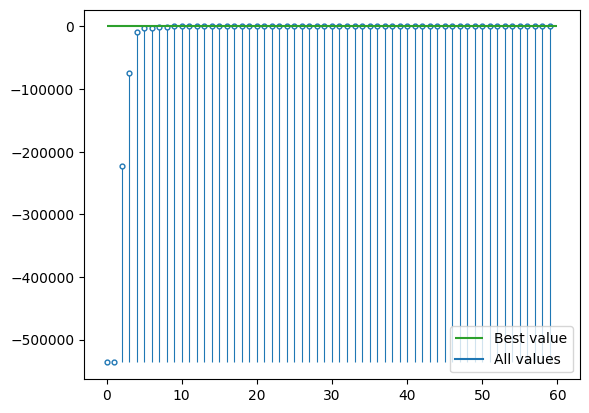

In [7]:
plot_bests(fy_hat_T)